In [ ]:
!pip install wbdata pandas matplotlib seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import wbdata
import datetime

In [ ]:
# Indicadores del Banco Mundial
indicadores = {
    "NY.GDP.MKTP.CD": "PIB (USD)",
    "NE.EXP.GNFS.ZS": "Exportaciones (% del PIB)",
    "NE.IMP.GNFS.ZS": "Importaciones (% del PIB)",
    "SL.UEM.TOTL.NE.ZS": "Tasa de desempleo",
    "FP.CPI.TOTL.ZG": "Inflación (CPI)",
    "BX.KLT.DINV.WD.GD.ZS": "Inversión extranjera directa (% del PIB)"
}

datos = wbdata.get_dataframe(indicadores)

In [ ]:
# Convertir fechas a datetime objects
datos.index = datos.index.set_levels(pd.to_datetime(datos.index.levels[1]), level=1)

fecha_inicio = datetime.datetime(2000, 1, 1)
fecha_fin = datetime.datetime(2024, 10, 31)

# Filtrar por el rango de fechas
datos_filtrados = datos[(datos.index.get_level_values(1) >= fecha_inicio) &
                        (datos.index.get_level_values(1) <= fecha_fin)]

In [ ]:
# Filtrar por países en desarrollo
paises_en_desarrollo = ["India", "Nigeria", "Brazil", "Indonesia", "South Africa", "Argentina",
                       "Mexico", "Colombia", "Chile", "Peru", "Egypt, Arab Rep.", "Philippines"]
datos_desarrollo = datos_filtrados[datos_filtrados.index.get_level_values(0).isin(paises_en_desarrollo)]

print(datos_desarrollo.isnull().sum())

# Mostrar las primeras filas
print(datos_desarrollo.head())

# Guardar el dataset
datos_desarrollo.to_csv("datos_economicos.csv")


PIB (USD)                                    0
Exportaciones (% del PIB)                   24
Importaciones (% del PIB)                   24
Tasa de desempleo                           38
Inflación (CPI)                             24
Inversión extranjera directa (% del PIB)     0
dtype: int64
                         PIB (USD)  Exportaciones (% del PIB)  \
country   date                                                  
Argentina 2023-01-01  6.405914e+11                  12.919425   
          2022-01-01  6.311334e+11                  16.299562   
          2021-01-01  4.879026e+11                  17.996588   
          2020-01-01  3.857405e+11                  16.605414   
          2019-01-01  4.477547e+11                  17.924878   

                      Importaciones (% del PIB)  Tasa de desempleo  \
country   date                                                       
Argentina 2023-01-01                  14.052392              6.139   
          2022-01-01                  1

In [ ]:
datos = pd.read_csv("datos_economicos.csv", index_col=[0, 1])

print(datos.head())
print(datos.info())

                         PIB (USD)  Exportaciones (% del PIB)  \
country   date                                                  
Argentina 2023-01-01  6.405914e+11                  12.919425   
          2022-01-01  6.311334e+11                  16.299562   
          2021-01-01  4.879026e+11                  17.996588   
          2020-01-01  3.857405e+11                  16.605414   
          2019-01-01  4.477547e+11                  17.924878   

                      Importaciones (% del PIB)  Tasa de desempleo  \
country   date                                                       
Argentina 2023-01-01                  14.052392              6.139   
          2022-01-01                  15.350952              6.805   
          2021-01-01                  14.933436              8.736   
          2020-01-01                  13.598284             11.461   
          2019-01-01                  14.705737              9.843   

                      Inflación (CPI)  \
country   da

PIB (USD)                                    0
Exportaciones (% del PIB)                   24
Importaciones (% del PIB)                   24
Tasa de desempleo                           38
Inflación (CPI)                             24
Inversión extranjera directa (% del PIB)     0
dtype: int64


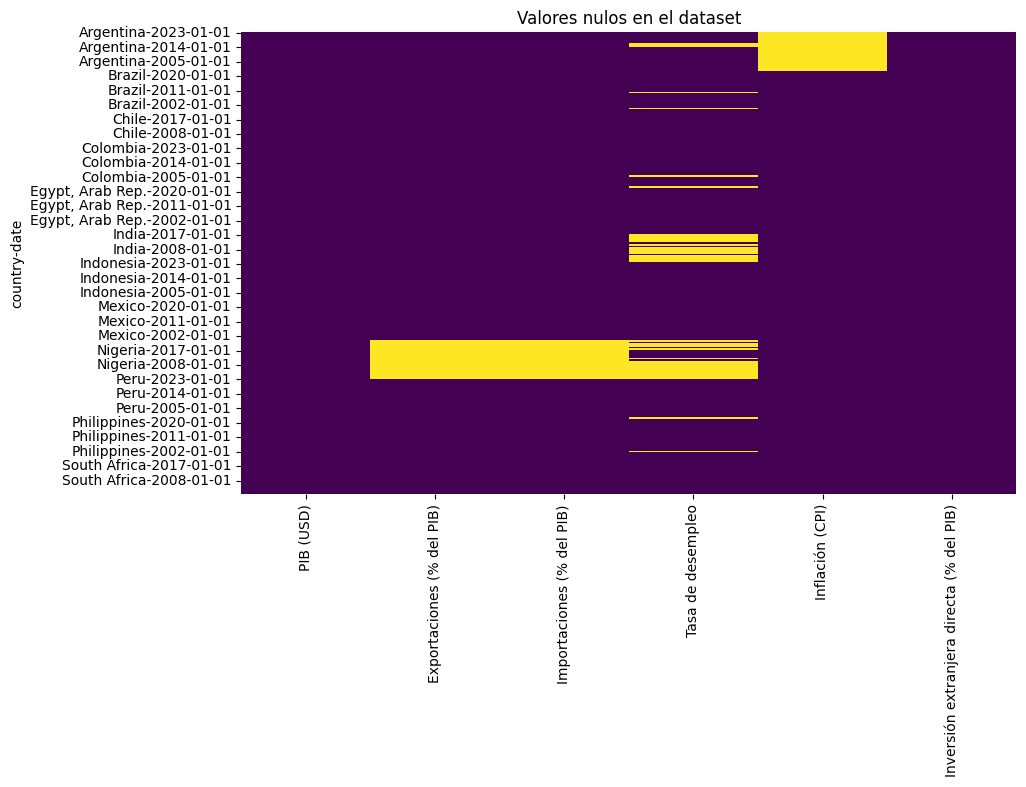

In [ ]:
print(datos.isnull().sum())

# Visualización de valores nulos
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(datos.isnull(), cbar=False, cmap="viridis")
plt.title("Valores nulos en el dataset")
plt.show()

In [ ]:
print(datos.describe())

          PIB (USD)  Exportaciones (% del PIB)  Importaciones (% del PIB)  \
count  2.880000e+02                 264.000000                 264.000000   
mean   6.181057e+11                  24.058050                  24.784506   
std    6.646913e+11                   8.211645                   7.969504   
min    5.174475e+10                  10.188048                  10.273247   
25%    2.050246e+11                  17.006145                  19.088414   
50%    3.467758e+11                  23.919425                  23.993108   
75%    7.997150e+11                  29.252239                  29.968918   
max    3.549919e+12                  45.129852                  45.687445   

       Tasa de desempleo  Inflación (CPI)  \
count         250.000000       264.000000   
mean            9.146200         6.236232   
std             6.684818         4.440813   
min             2.237000        -0.692030   
25%             4.071500         3.516029   
50%             7.600500         5.0

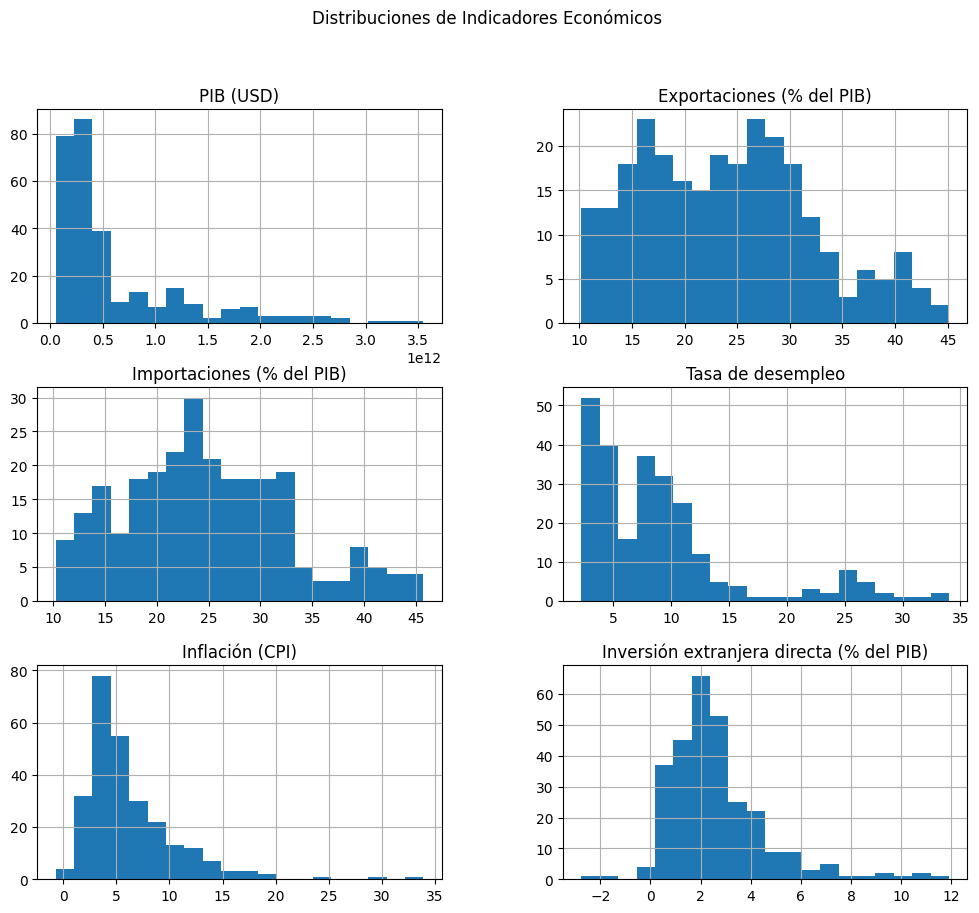

In [ ]:
# Histograma para cada indicador
datos.hist(bins=20, figsize=(12, 10))
plt.suptitle("Distribuciones de Indicadores Económicos")
plt.show()

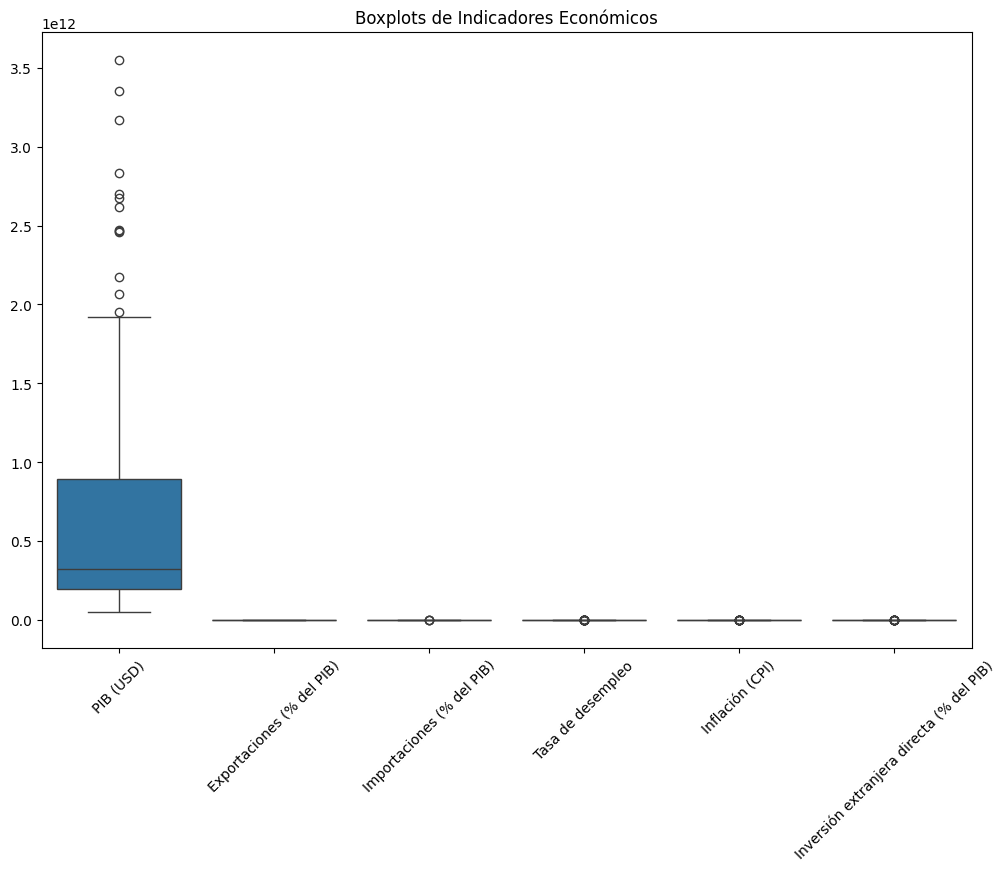

In [ ]:
import seaborn as sns

# Crear boxplots para cada indicador
plt.figure(figsize=(12, 8))
sns.boxplot(data=datos.dropna())
plt.xticks(rotation=45)
plt.title("Boxplots de Indicadores Económicos")
plt.show()

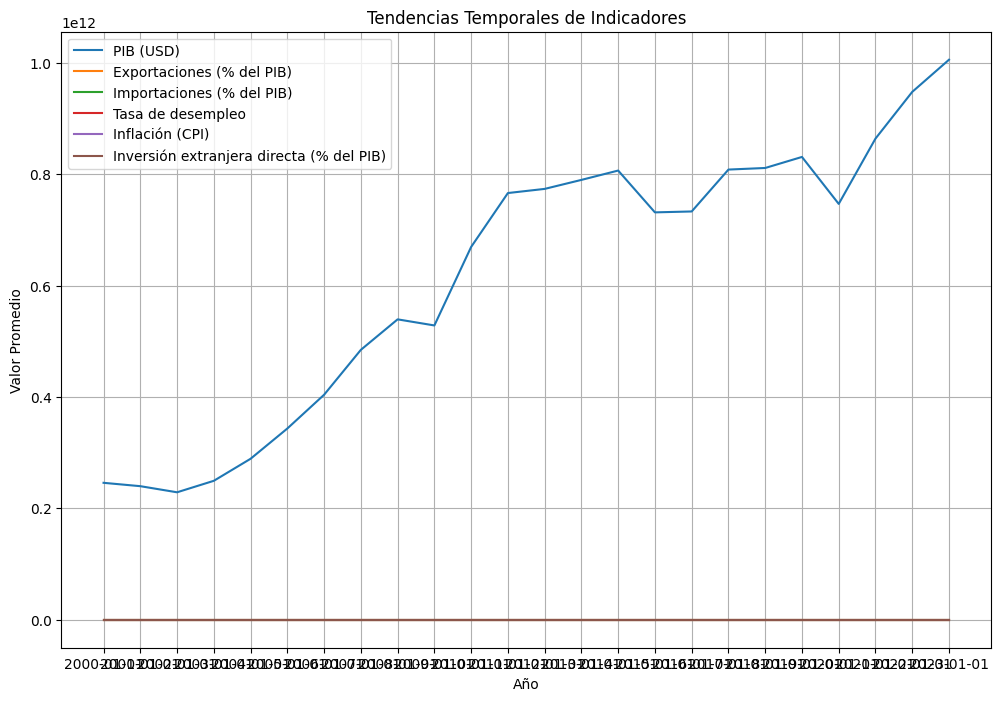

In [ ]:
# Agrupar por años y calcular la media
datos_temporales = datos.groupby(level=1).mean()

# Graficar las tendencias
plt.figure(figsize=(12, 8))
for columna in datos_temporales.columns:
    plt.plot(datos_temporales.index, datos_temporales[columna], label=columna)

plt.title("Tendencias Temporales de Indicadores")
plt.xlabel("Año")
plt.ylabel("Valor Promedio")
plt.legend()
plt.grid()
plt.show()

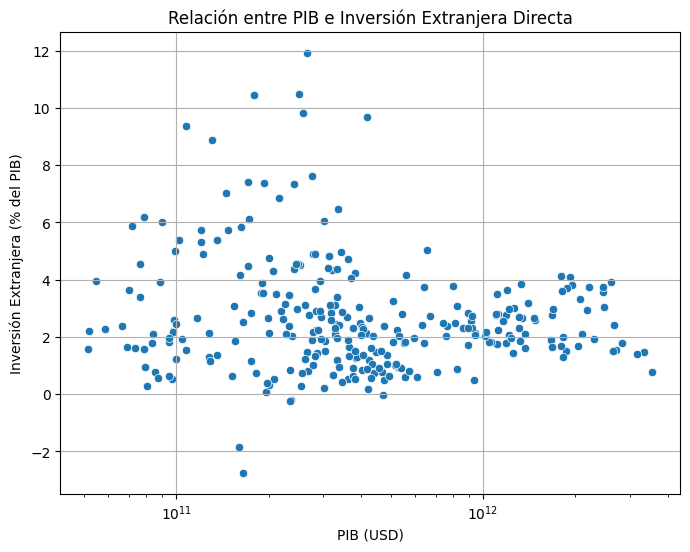

In [ ]:
# Scatterplot de PIB vs Inversión Extranjera
plt.figure(figsize=(8, 6))
sns.scatterplot(data=datos, x="PIB (USD)", y="Inversión extranjera directa (% del PIB)")
plt.title("Relación entre PIB e Inversión Extranjera Directa")
plt.xscale("log")  # Escala logarítmica para manejar el rango del PIB
plt.ylabel("Inversión Extranjera (% del PIB)")
plt.xlabel("PIB (USD)")
plt.grid()
plt.show()

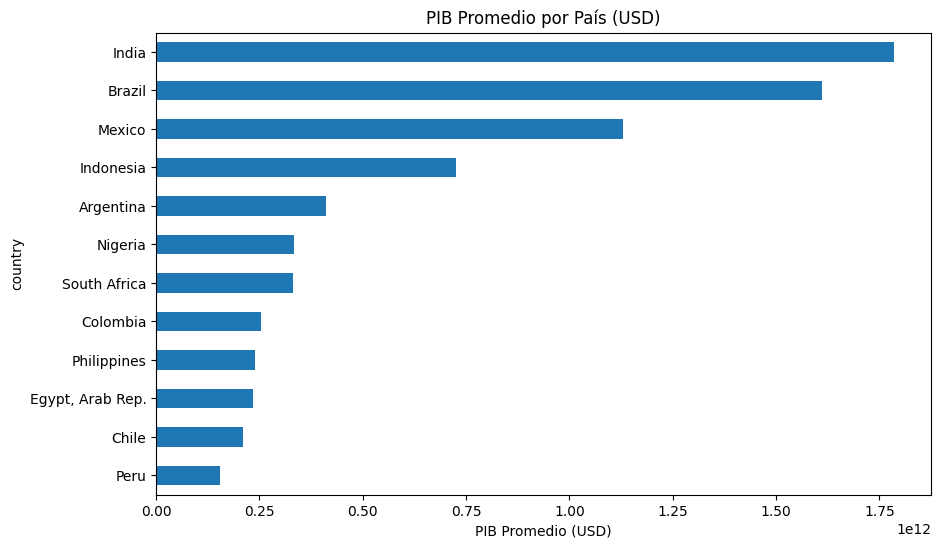

In [ ]:
# Agrupar por país y calcular la media de cada indicador
datos_por_pais = datos.groupby(level=0).mean()

# Gráfico de barras para PIB por país
plt.figure(figsize=(10, 6))
datos_por_pais["PIB (USD)"].sort_values().plot(kind="barh")
plt.title("PIB Promedio por País (USD)")
plt.xlabel("PIB Promedio (USD)")
plt.show()

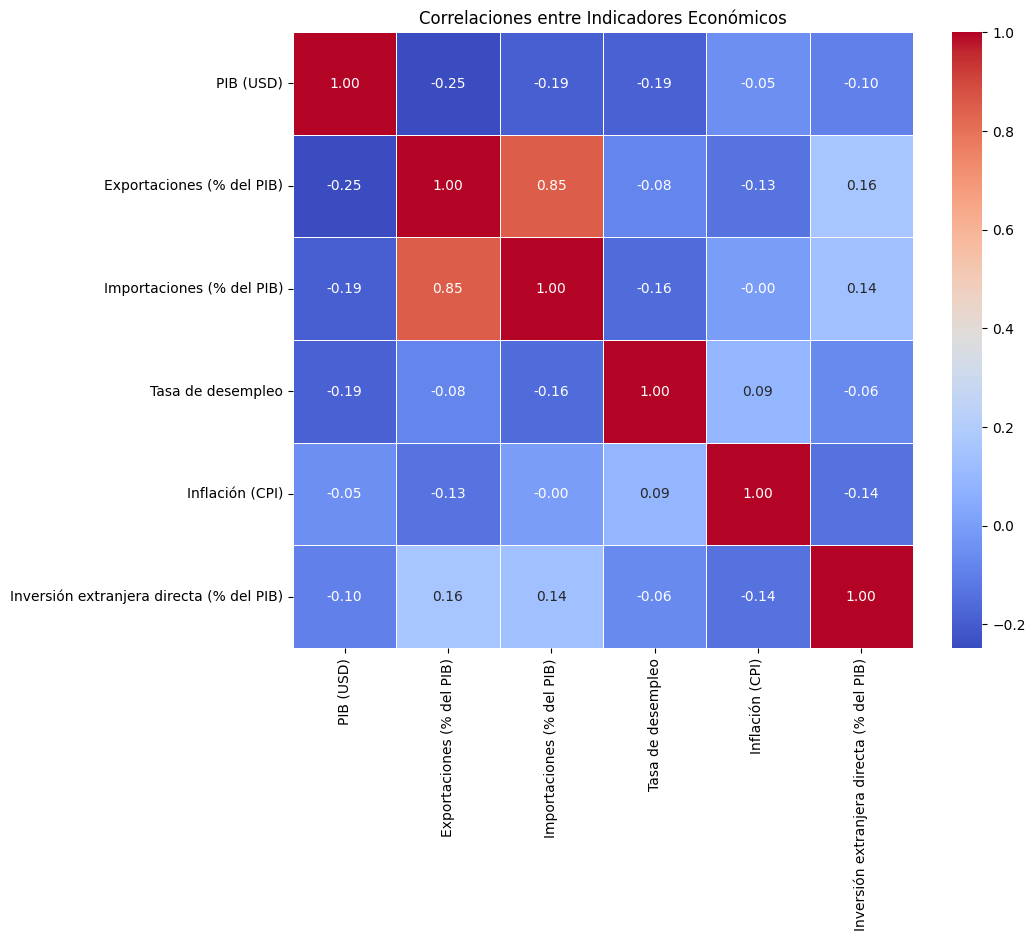

In [ ]:
# Matriz de correlación con anotaciones más detalladas
plt.figure(figsize=(10, 8))
sns.heatmap(datos.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlaciones entre Indicadores Económicos")
plt.show()

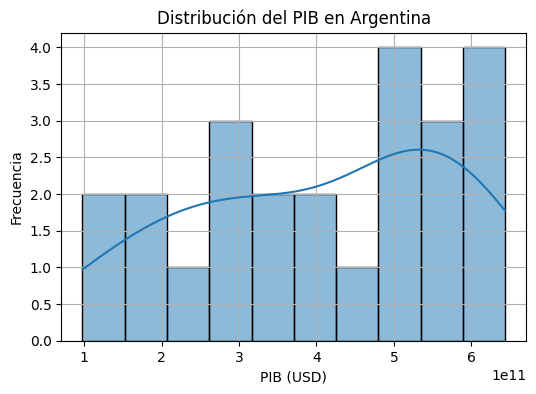

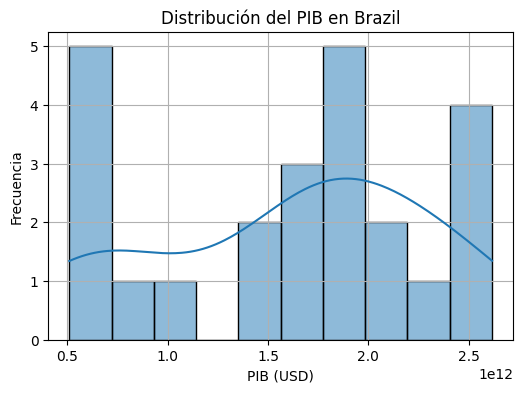

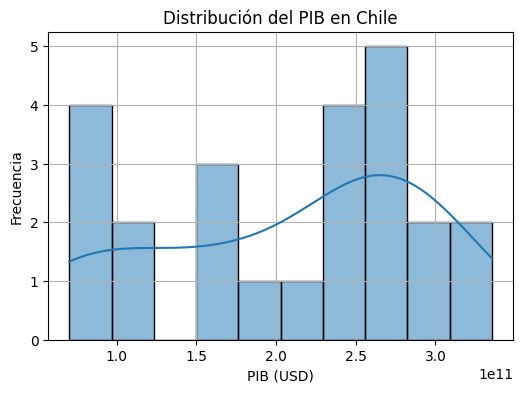

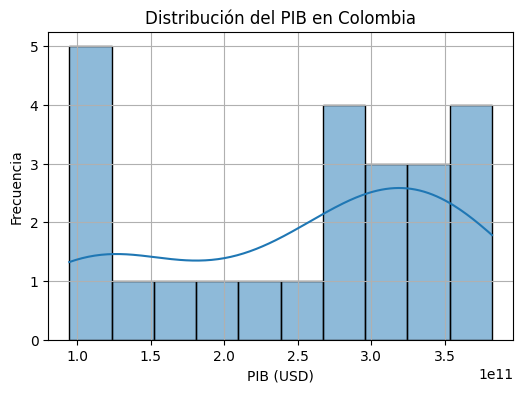

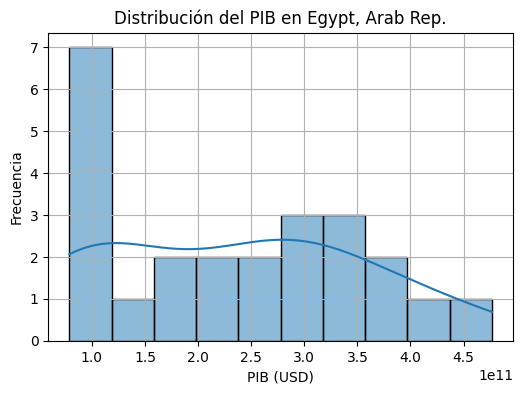

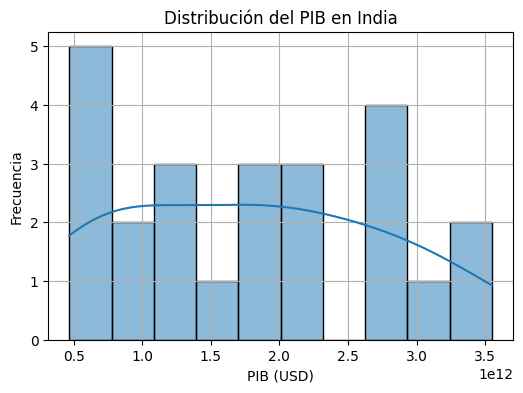

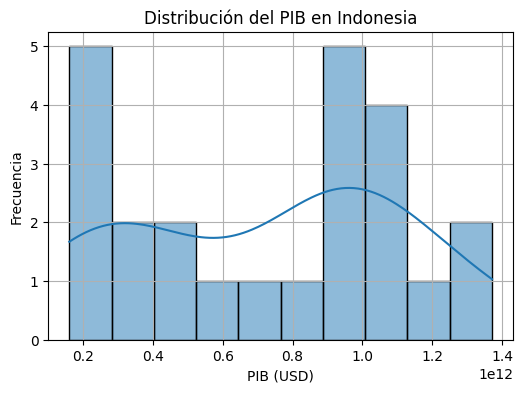

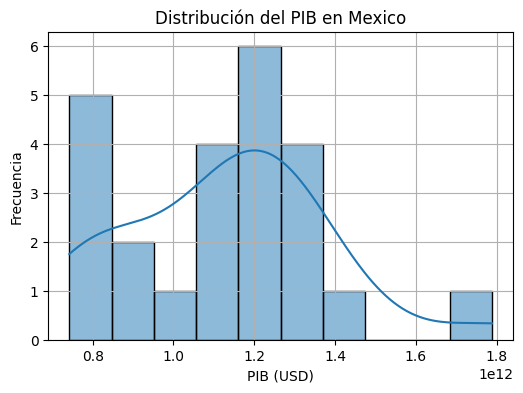

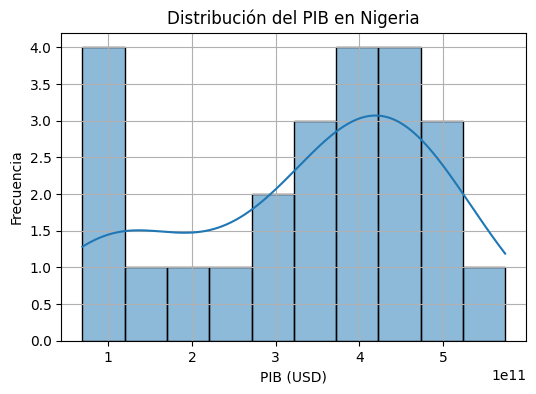

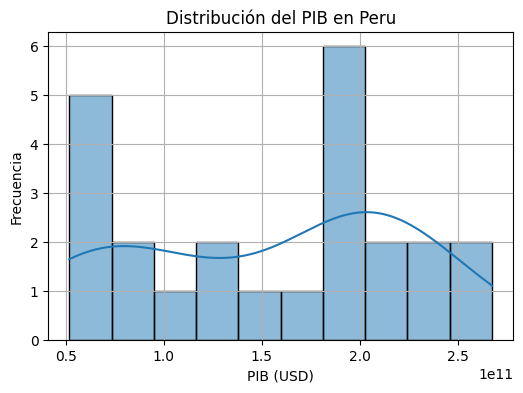

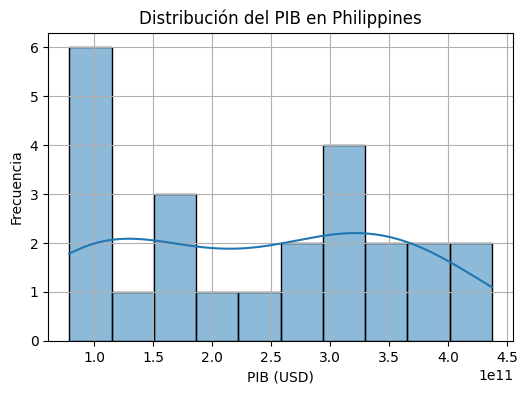

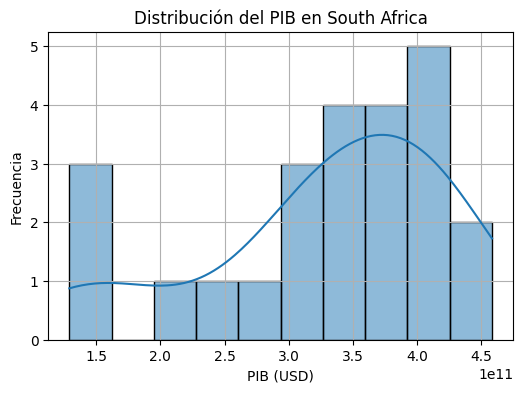

In [ ]:
# Histograma por país (ejemplo: PIB)
for pais in datos.index.get_level_values(0).unique():
    plt.figure(figsize=(6, 4))
    sns.histplot(datos.loc[pais, "PIB (USD)"], bins=10, kde=True)
    plt.title(f"Distribución del PIB en {pais}")
    plt.xlabel("PIB (USD)")
    plt.ylabel("Frecuencia")
    plt.grid()
    plt.show()